In [43]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from metpy.interpolate import cross_section
import pandas as pd
from pandas.tseries.offsets import DateOffset
import numpy as np
plt.rcParams.update({'font.size': 20})
import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df

In [44]:
### Bathymétrie
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]

### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")

### Datasets
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS")
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL")

ds_section = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/GLORYS/GLORYS_1000m_section_plot.nc")
ds_section_mld = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/GLORYS/GLORYS_2026_with_mld.nc")

ds_section = xr.merge([ds_section, ds_section_mld.mld])

204
204
204


In [45]:
ds_coef = ds_G.mean("time").metpy.parse_cf().squeeze()
data_c = ds_section.metpy.parse_cf().squeeze()

In [46]:
### Cross section
start_c1 =(72,-52.5)
end_c1 = (79,-47)
cross_c1 = cross_section(data_c, start_c1[::-1], end_c1[::-1])
cross_coef1 = cross_section(ds_coef.mld, start_c1[::-1], end_c1[::-1])
cross_xiphi1 = cross_section(ds_coef.xi_phi1, start_c1[::-1], end_c1[::-1])

### Elevation cross section
cross_el1 = cross_section(-elevation.to_dataset().metpy.parse_cf(),start_c1[::-1], end_c1[::-1])

Could not find variable corresponding to the value of grid_mapping: crs


In [47]:
def zero_crossings_1d(da, x_coord="long", atol=1e-12):
    """
    Return zero-crossing x locations for a 1D DataArray using linear interpolation.
    Also includes exact zeros (within atol).
    """
    x = da[x_coord].values
    y = da.values

    # Keep only finite pairs
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    # Sign changes between consecutive points
    idx = np.where(np.signbit(y[:-1]) != np.signbit(y[1:]))[0]

    # Linear interpolation for crossing location
    den = y[idx + 1] - y[idx]
    ok = ~np.isclose(den, 0.0, atol=atol)
    x_interp = x[idx[ok]] - y[idx[ok]] * (x[idx[ok] + 1] - x[idx[ok]]) / den[ok]

    # Exact zeros
    x_exact = x[np.isclose(y, 0.0, atol=atol)]

    # Combined unique values
    return np.unique(np.concatenate([x_interp, x_exact]))


x_zero_xiphi1 = zero_crossings_1d(cross_xiphi1, x_coord="long")

if x_zero_xiphi1.size == 0:
    print("No zero crossing found for cross_xiphi1.")
else:
    print("cross_xiphi1 zero-crossing longitude(s):", x_zero_xiphi1)


cross_xiphi1 zero-crossing longitude(s): [74.64577219]


<xarray.DataArray 'mld' (index: 100)> Size: 800B
array([108.30280301, 105.41288796, 102.52297291, 117.22024137,
       118.67824593, 118.78922654, 119.37174219, 119.13078047,
       119.52953484, 119.78097111, 119.91380663, 119.41078194,
       118.60549993, 118.00527879, 118.06457103, 116.32303877,
       114.85694744, 115.73025778, 116.17046044, 115.34364348,
       113.12904539, 111.52600197, 110.50035057, 108.29661325,
       107.56879703, 107.41430043, 106.18864225, 104.59231306,
       103.68244188, 102.87728397, 102.74137653, 102.73492318,
       102.69886756, 101.05495264,  99.0747649 ,  98.03853644,
        97.2312008 ,  96.75173369,  96.37408535,  95.45968515,
        94.04950544,  93.19531627,  92.88387366,  93.26442723,
        92.54839646,  91.34860373,  90.11637648,  88.26890681,
        85.86956608,  83.15868696,  81.73927024,  80.1956841 ,
        79.0498174 ,  78.01962274,  77.87247036,  77.78520381,
        76.56278351,  75.15741405,  74.18482328,  73.47399155,
        73.25916716,  73.3523414 ,  73.64031282,  73.64201259,
        73.39514638,  73.09653793,  72.61226738,  72.36142015,
        72.01797086,  71.50256225,  71.17942082,  71.07733651,
        71.10916637,  71.34594537,  70.81458327,  70.54612163,
        70.51357616,  70.55762566,  70.85597915,  71.09602692,
        71.1544628 ,  71.41353189,  71.81831083,  72.10479461,
        71.79232378,  71.80919984,  72.11372826,  72.67625235,
        73.11627337,  73.14254341,  72.84648829,  72.46159475,
        72.16153654,  71.72432191,  71.95050015,  72.25057238,
        73.02172816,  73.40388904,  73.59226426,  74.05348568])
Coordinates:
    metpy_crs  object 8B Projection: latitude_longitude
    longitude  (index) float64 800B 72.0 72.08 72.16 72.24 ... 78.87 78.94 79.0
    latitude   (index) float64 800B -52.5 -52.45 -52.39 ... -47.12 -47.06 -47.0
  * index      (index) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99

In [52]:
### Correcting outliers in MLD section by interpolation

mld_sec = cross_c1.mean(dim=["depth", "time"]).mld.copy()

# Section dimension (typically "index")
sec_dim = mld_sec.dims[0]

# Mark the 2nd point as missing, then interpolate from neighbors
mld_sec_corr = mld_sec.copy()
mld_sec_corr[{sec_dim: 1}] = np.nan
mld_sec_corr = mld_sec_corr.interpolate_na(dim=sec_dim, method="linear")

cross_c1["mld"] = mld_sec_corr

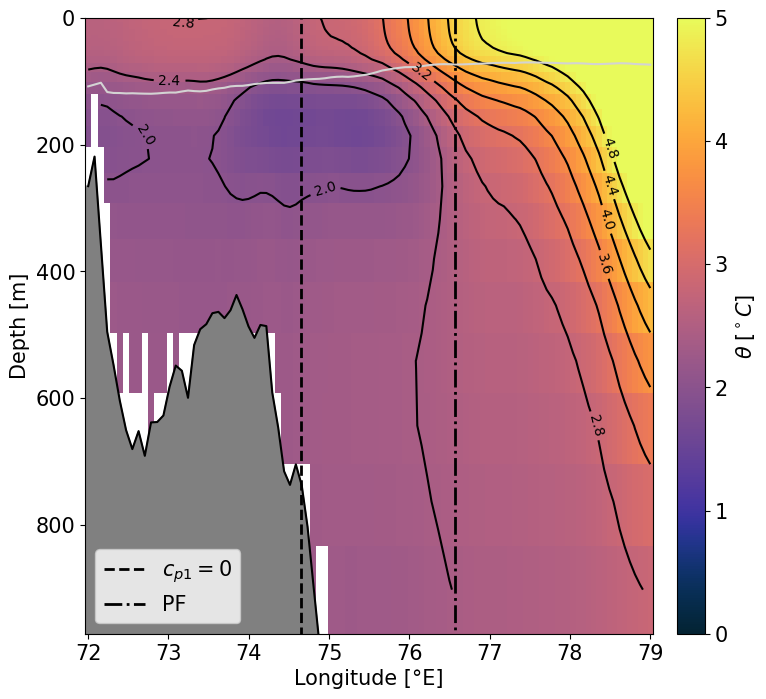

In [61]:
plt.rcParams.update({'font.size': 15})
lon_intersection = x_zero_xiphi1

# Polar Front position projected on section 1 (nearest PF point to section track)
pf_lon = ds_front["LonPF"].values
pf_lat = ds_front["LatPF"].values
m_pf = np.isfinite(pf_lon) & np.isfinite(pf_lat)
pf_lon = pf_lon[m_pf]
pf_lat = pf_lat[m_pf]

sec_lon = cross_coef1["long"].values
sec_lat = cross_coef1["lat"].values
dist2 = (pf_lon[:, None] - sec_lon[None, :])**2 + (pf_lat[:, None] - sec_lat[None, :])**2
i_pf, _ = np.unravel_index(np.argmin(dist2), dist2.shape)
pf_lon_section = float(pf_lon[i_pf])

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 0.05],
    wspace=0.08
)

axa = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

cp = cross_c1.thetao.mean("time").plot.contour(
    x="longitude", y="depth", yincrease=False,
    colors="black", ax=axa, levels=np.linspace(0, 4.8, 13)
)
plt.clabel(cp, inline=True, fontsize=10)

pcm = cross_c1.thetao.mean("time").plot(
    x="longitude", y="depth", yincrease=False,
    ax=axa, cmap="cmo.thermal", vmin=0, vmax=5,
    add_colorbar=False
)

cross_c1.mean(dim=["depth", "time"]).mld.plot(x="longitude", color="lightgrey", ax=axa)
axa.fill_betweenx(cross_el1.elevation, cross_el1.lon, color="grey")
cross_el1.elevation.plot(x="lon", ax=axa, color="black")

axa.set_ylabel("Depth [m]")
axa.set_xlabel("Longitude [°E]")
axa.vlines(lon_intersection, 1000, 0, ls="--", color="k", lw=2,label="$c_{p1} = 0$")
axa.vlines(pf_lon_section, 1000, 0, ls="-.", color="k", lw=2,label="PF")
axa.set_title("")
axa.legend()
fig.colorbar(pcm, cax=cax, label=r"$\theta \; [^\circ C]$")
# plt.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_9_sections.png", bbox_inches="tight", dpi=300)